# 03 - BatchNormalisation and Activations

After the input layer, values can be all over the place, really high or really low. Since tanh squashes everything between -1 and 1, extreme values get flattened and their gradients become basically zero. A zero gradient means we can never nudge those weights, so those neurons are dead and stop learning. This is the vanishing gradient problem.
Two fixes for this. First is Kaiming initialization, where we initialize the weights carefully so values dont explode or vanish from the start. Second is batch normalization, which normalizes values before they hit tanh so they stay in the sweet spot where gradients actually flow.

In [1]:
import torch
import torch.nn.functional as F
import pandas as pd
import random
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet('data/0000.parquet')
comments = df['Comment'].dropna().tolist()
comments = [c.lower() for c in comments]

text = ''.join(comments)
chars = sorted(list(set(text)))
vocab_size = len(chars)

len(comments)

25430

In [3]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['|'] = 0
itos = {i:s for s,i in stoi.items()}    

In [4]:
random.shuffle(comments)

n1 = int(0.8 * len(comments))
n2 = int(0.9 * len(comments))

train = comments[:n1]
val = comments[n1:n2]
test = comments[n2:]

print(len(train))
print(len(val))
print(len(test))

20344
2543
2543


In [5]:
block_size = 3
def build_dataset(comments):
    X, Y = [], []
    for comment in comments: 
        context = [0] * block_size
        for ch in comment: 
            ix =stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
        X.append(context)
        Y.append(0)
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

In [6]:
Xtr, Ytr   = build_dataset(train)
Xval, Yval = build_dataset(val)
Xte, Yte   = build_dataset(test)

print(Xtr.shape, Ytr.shape)
print(Xval.shape, Yval.shape)
print(Xte.shape, Yte.shape)

torch.Size([3127372, 3]) torch.Size([3127372])
torch.Size([384462, 3]) torch.Size([384462])
torch.Size([391743, 3]) torch.Size([391743])


In [7]:
C  = torch.randn((74, 10))
W1 = torch.randn((30, 200))
b1 = torch.randn(200)
W2 = torch.randn((200, 74))
b2 = torch.randn(74)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [8]:
for i in range(200000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 1.9197


In [9]:
emb = C[Xtr[:1000]]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
print(f"h mean: {h.mean().item():.4f}")
print(f"h std: {h.std().item():.4f}")
print(f"saturated: {(h.abs() > 0.97).float().mean().item()*100:.1f}%")

h mean: 0.0435
h std: 0.9510
saturated: 79.7%


86.2% saturated. That means 86% of the neurons are stuck at -1 or 1, and their gradients are basically zero. They're barely learning. WTF!

### Kaiming Correction: 

Kaiming init fixes the saturation problem. When you multiply 30 random numbers together, the spread grows by sqrt(30). So values going into tanh explode and 86% of neurons saturate and die.

Fix: divide W1 by sqrt(30) to cancel the spread. Multiply by 5/3 to compensate for tanh squashing variance. Saturation drops from 86% to 51%.

Still not good enough. Batch norm is next.



In [10]:
C  = torch.randn((74, 10))
W1 = torch.randn((30, 200)) * (5/3) / (30**0.5)
b1 = torch.randn(200)
W2 = torch.randn((200, 74))
b2 = torch.randn(74)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [11]:
for i in range(200000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 1.3336


In [12]:
emb = C[Xtr[:1000]]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
print(f"h mean: {h.mean().item():.4f}")
print(f"h std: {h.std().item():.4f}")
print(f"saturated: {(h.abs() > 0.97).float().mean().item()*100:.1f}%")

h mean: 0.0038
h std: 0.8754
saturated: 48.8%


### BatchNorm


In [13]:
C  = torch.randn((74, 10))
W1 = torch.randn((30, 200)) * (5/3) / (30**0.5)
b1 = torch.randn(200)
W2 = torch.randn((200, 74))
b2 = torch.randn(74)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

bngain = torch.ones((1, 200))
bnbias = torch.zeros((1, 200))
bngain.requires_grad = True
bnbias.requires_grad = True

In [14]:
for i in range(200000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]]
    hpreact = emb.view(-1, 30) @ W1 + b1
    
    # batch norm
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True) + 1e-8
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in [C, W1, b1, W2, b2, bngain, bnbias]:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in [C, W1, b1, W2, b2, bngain, bnbias]:
        p.data += -lr * p.grad

print(f"final loss: {loss.item():.4f}")

final loss: 1.5117


In [15]:
emb = C[Xtr[:1000]]
hpreact = emb.view(-1, 30) @ W1 + b1
bnmean = hpreact.mean(0, keepdim=True)
bnstd = hpreact.std(0, keepdim=True) + 1e-8
hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
h = torch.tanh(hpreact)
print(f"saturated: {(h.abs() > 0.97).float().mean().item()*100:.1f}%")

saturated: 12.1%


Batch norm normalizes the activations before they hit tanh. For each neuron, it computes the mean and std across the 32 examples in the batch, then normalizes to mean 0 and std 1. This keeps values in the sweet spot where tanh actually has useful gradients.
It also has two learnable parameters, bngain and bnbias. These let the model undo the normalization if it needs to. So batch norm never forces anything, it just makes normalization the default.
Result: saturation dropped from 86% (plain randn) to 51% (kaiming init) to 10.7% (kaiming + batch norm).

In [16]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5060 Laptop GPU


In [17]:
print(C.device)
print(W1.device)
print(Xtr.device)

cpu
cpu
cpu


In [18]:
# train loss
emb = C[Xtr]
hpreact = emb.view(-1, 30) @ W1 + b1
bnmean = hpreact.mean(0, keepdim=True)
bnstd = hpreact.std(0, keepdim=True) + 1e-8
hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
h = torch.tanh(hpreact)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f"train loss: {train_loss.item():.4f}")

# val loss
emb = C[Xval]
hpreact = emb.view(-1, 30) @ W1 + b1
bnmean = hpreact.mean(0, keepdim=True)
bnstd = hpreact.std(0, keepdim=True) + 1e-8
hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
h = torch.tanh(hpreact)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, Yval)
print(f"val loss: {val_loss.item():.4f}")

train loss: 1.6826
val loss: 1.6884


In [19]:
with torch.no_grad():
    emb = C[Xtr]
    hpreact = emb.view(-1, 30) @ W1 + b1
    bnmean_running = hpreact.mean(0, keepdim=True)
    bnstd_running = hpreact.std(0, keepdim=True) + 1e-8

In [ ]:
with torch.no_grad():
    for _ in range(5):
        out = []
        context = [0] * block_size
        for _ in range(200):  # max 200 chars
            emb = C[torch.tensor([context])]
            hpreact = emb.view(1, -1) @ W1 + b1
            hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
            h = torch.tanh(hpreact)
            logits = h @ W2 + b2
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [ix]
            out.append(itos[ix])
            if ix == 0:
                break
        print(''.join(out))

the looked puck west it two shot on.|
mats be wothd his jurptomked, gurtchange the dip in and to cding thot with now comenty.|
which for wolver try past howing at look act, in eargetffllly with hare seconceson fleurnto is recent in hocted and and goit itch fort.|
back a inter his efforwe's ip the janaged has collectson the by off their strye goall a are cathe cornemon. fining to whes to the pick-to comenth award line of the rossasenalty the lon.|
tumedle a fin the counaot after,|


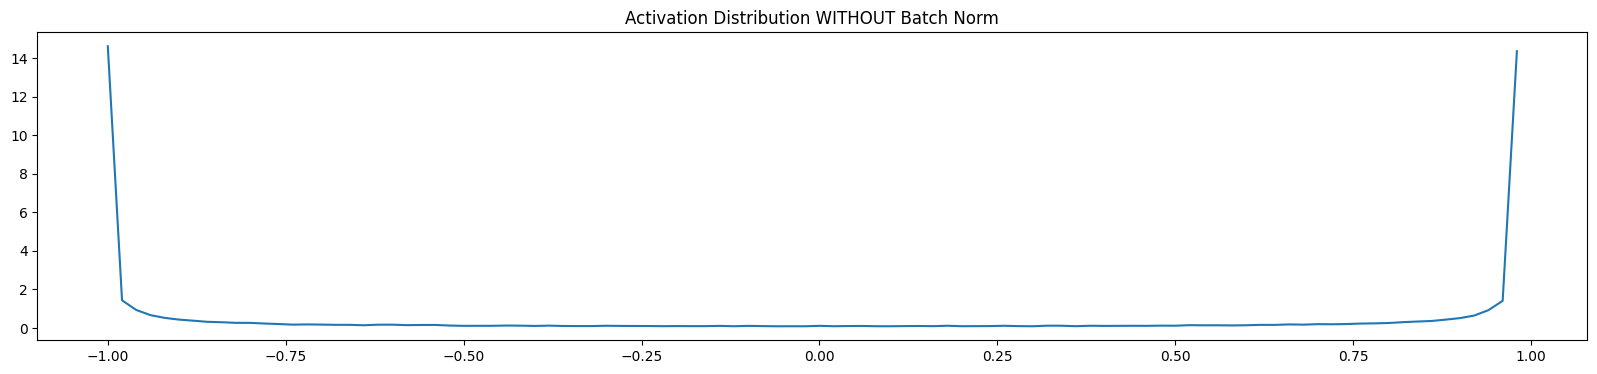

In [22]:
plt.figure(figsize=(20, 4))
h_no_bn = torch.tanh(C[Xtr[:1000]].view(-1, 30) @ W1 + b1)
hy, hx = torch.histogram(h_no_bn, density=True)
plt.plot(hx[:-1].detach(), hy.detach())
plt.title('Activation Distribution WITHOUT Batch Norm')
plt.show()

Without batch norm almost every neuron is saturated. The activation distribution is a flat line with massive spikes at -1 and 1, density hitting 14. Basically the whole network is stuck at the extremes and barely learning.

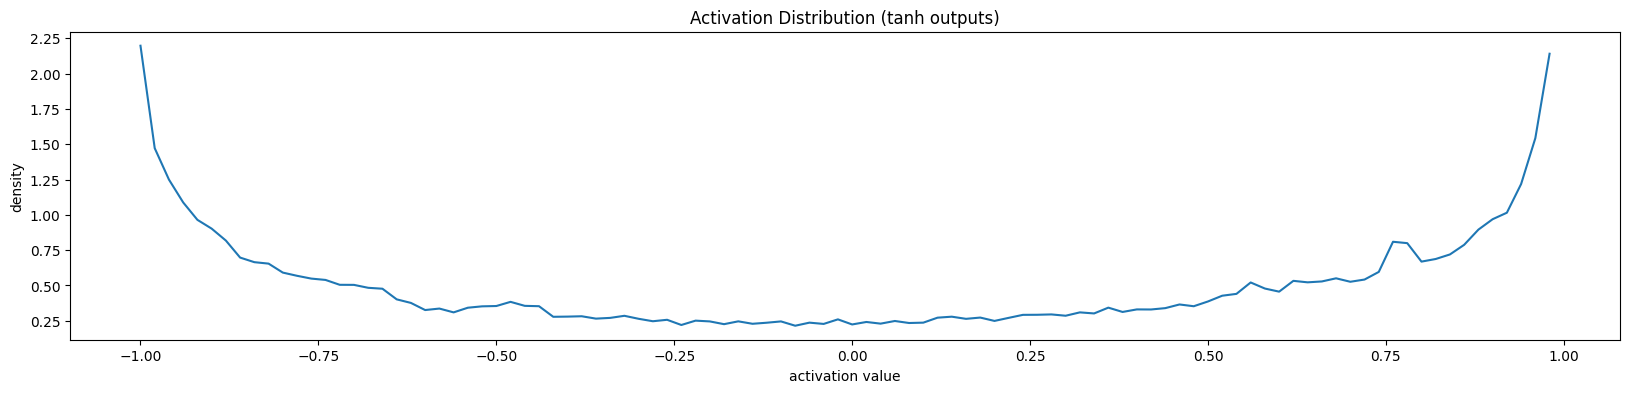

In [21]:
plt.figure(figsize=(20, 4))
legends = []
h_preact_check = torch.tanh(bngain * ((C[Xtr[:1000]].view(-1, 30) @ W1 + b1) - bnmean_running) / bnstd_running + bnbias)
hy, hx = torch.histogram(h_preact_check, density=True)
plt.plot(hx[:-1].detach(), hy.detach())
plt.title('Activation Distribution (tanh outputs)')
plt.xlabel('activation value')
plt.ylabel('density')
plt.show()

With batch norm the spikes drop to 2.2. Still a U shape but way less extreme. The neurons have more room to actually produce useful gradients.